# Benchmarking – Summary:

## 1) Imports and Set-Up:

### 1.1) Imports & Seed-Setting:

In [51]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import to_rgb

### 1.2) Helper-Functions:

In [21]:
# io – read all benchmark csvs
def _coerce_bool(s: pd.Series) -> pd.Series:
    if s.dtype == bool:
        return s
    if pd.api.types.is_numeric_dtype(s):
        return s.fillna(0).astype(int).astype(bool)
    # strings / objects
    x = s.astype(str).str.strip().str.lower()
    true_vals = {"true", "t", "1", "yes", "y"}
    false_vals = {"false", "f", "0", "no", "n"}
    out = pd.Series(np.nan, index=s.index, dtype="float")
    out[x.isin(true_vals)] = 1.0
    out[x.isin(false_vals)] = 0.0
    return out.fillna(0.0).astype(int).astype(bool)


def load_benchmark_csvs(results_dir: str | Path, pattern: str = "results_*.csv") -> pd.DataFrame:
    results_dir = Path(results_dir)
    paths = sorted(results_dir.glob(pattern))
    if not paths:
        raise FileNotFoundError(f"no files matching {pattern} in {results_dir.resolve()}")

    dfs = []
    for p in paths:
        df = pd.read_csv(p)

        stem = p.stem
        benchmark = stem[len("results_"):] if stem.startswith("results_") else stem
        df["benchmark"] = benchmark
        df["source_file"] = p.name
        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)

    for col in ["difficulty", "true_k", "k", "dataset_id"]:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce").astype("Int64")

    for col in ["is_optimal", "is_correct"]:
        if col in out.columns:
            out[col] = _coerce_bool(out[col])

    return out

def instance_key_cols(df: pd.DataFrame) -> list[str]:
    base = ["benchmark", "metric_name", "dataset_id", "true_k"]
    condition_cols = []
    for c in ["difficulty", "p", "n_samples"]: 
        if c in df.columns and df[c].notna().any():
            condition_cols.append(c)
    return base + condition_cols


# overall k-recovery summary
def wilson_ci(successes: int, n: int, z: float = 1.96) -> tuple[float, float]:
    if n <= 0:
        return (np.nan, np.nan)
    p = successes / n
    denom = 1.0 + (z**2) / n
    center = (p + (z**2) / (2 * n)) / denom
    half = (z * np.sqrt((p * (1 - p) + (z**2) / (4 * n)) / n)) / denom
    return (max(0.0, center - half), min(1.0, center + half))


def summarize_true_k_accuracy(results: pd.DataFrame) -> pd.DataFrame:
    sel = results.loc[results["is_optimal"]].copy()

    key_cols = instance_key_cols(sel)
    if sel.duplicated(key_cols).any():
        sel = sel.sort_values(key_cols + ["k"]).drop_duplicates(key_cols, keep="first")

    sel["k_error"] = (sel["k"] - sel["true_k"]).astype(float)
    sel["abs_k_error"] = sel["k_error"].abs()
    sel["over"] = sel["k_error"] > 0
    sel["under"] = sel["k_error"] < 0

    g = (
        sel.groupby("metric_name", as_index=False)
           .agg(
               n=("is_correct", "size"),
               correct=("is_correct", "sum"),
               accuracy=("is_correct", "mean"),
               mae_k=("abs_k_error", "mean"),
               bias_k=("k_error", "mean"),
               over_rate=("over", "mean"),
               under_rate=("under", "mean"),
           )
    )

    ci = [wilson_ci(int(r.correct), int(r.n)) for r in g.itertuples(index=False)]
    g["acc_ci_low"] = [c[0] for c in ci]
    g["acc_ci_high"] = [c[1] for c in ci]
    g["accuracy_ci"] = g.apply(
        lambda r: f"{r.accuracy:.3f} [{r.acc_ci_low:.3f}, {r.acc_ci_high:.3f}]",
        axis=1
    )

    return g.sort_values(["accuracy", "mae_k"], ascending=[False, True]).reset_index(drop=True)


# def summarize_true_k_accuracy_macro(results: pd.DataFrame) -> pd.DataFrame:
#     sel = results.loc[results["is_optimal"]].copy()
    
#     key_cols = instance_key_cols(sel)
#     if sel.duplicated(key_cols).any():
#         sel = sel.sort_values(key_cols + ["k"]).drop_duplicates(key_cols, keep="first")

#     sel["k_error"] = (sel["k"] - sel["true_k"]).astype(float)
#     sel["abs_k_error"] = sel["k_error"].abs()
#     sel["over"] = sel["k_error"] > 0
#     sel["under"] = sel["k_error"] < 0

#     per_bench = (
#         sel.groupby(["benchmark", "metric_name"], as_index=False)
#            .agg(
#                acc=("is_correct", "mean"),
#                mae=("abs_k_error", "mean"),
#                bias=("k_error", "mean"),
#                over_rate=("over", "mean"),
#                under_rate=("under", "mean"),
#            )
#     )

#     macro = (
#         per_bench.groupby("metric_name", as_index=False)
#                  .agg(
#                      benchmarks=("benchmark", "nunique"),
#                      acc_macro=("acc", "mean"),
#                      acc_macro_sd=("acc", "std"),
#                      mae_macro=("mae", "mean"),
#                      bias_macro=("bias", "mean"),
#                      over_rate_macro=("over_rate", "mean"),
#                      under_rate_macro=("under_rate", "mean"),
#                  )
#                  .fillna({"acc_macro_sd": 0.0})
#                  .sort_values(["acc_macro", "mae_macro"], ascending=[False, True])
#                  .reset_index(drop=True)
#     )
#     return macro


def best_metric_per_benchmark(results: pd.DataFrame) -> pd.DataFrame:
    sel = results.loc[results["is_optimal"]].copy()
    
    key_cols = instance_key_cols(sel)
    if sel.duplicated(key_cols).any():
        sel = sel.sort_values(key_cols + ["k"]).drop_duplicates(key_cols, keep="first")

    sel["abs_k_error"] = (sel["k"] - sel["true_k"]).abs().astype(float)

    per = (
        sel.groupby(["benchmark", "metric_name"], as_index=False)
           .agg(
               n=("is_correct", "size"),
               accuracy=("is_correct", "mean"),
               mae_k=("abs_k_error", "mean"),
           )
    )

    winners = (
        per.sort_values(["benchmark", "accuracy", "mae_k", "metric_name"], ascending=[True, False, True, True])
           .groupby("benchmark", as_index=False)
           .head(1)
           .reset_index(drop=True)
    )
    return winners

In [65]:
PLOT_METRICS = [
    "ari_average_1se",
    "ari_generalizability_1se",
    "ari_stability_1se",
    "silhouette",
    "gap",
    "davies_bouldin",
    "calinski_harabasz",
]

PLOT_METRICS_CARVE = [
    "ari_average_1se",
    "ari_generalizability_1se",
    "ari_stability_1se",
]

PLOT_METRICS_EXT = [
    "ari_average_1se",
    "silhouette",
    "gap",
    "davies_bouldin",
    "calinski_harabasz",
]

METRIC_COLOR = {
    "ari_average_1se":         "#2B8CBE",  # blue
    "ari_generalizability_1se":"#3B5BA9",  # indigo
    "ari_stability_1se":       "#5E3C99",  # purple
    "silhouette":              "#8E3B9E",  # purple-magenta
    "gap":                     "#C03A8C",  # magenta
    "davies_bouldin":          "#E457A1",  # pink
    "calinski_harabasz":       "#D53E4F",  # red
}

METRIC_LABEL = {
    "ari_average_1se": "ARI (avg, 1se)",
    "ari_generalizability_1se": "ARI (gen, 1se)",
    "ari_stability_1se": "ARI (stab, 1se)",
    "silhouette": "Silhouette",
    "gap": "Gap",
    "davies_bouldin": "DB",
    "calinski_harabasz": "CH",
}


def set_paper_style():
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.18,
        "grid.linewidth": 0.6,
        "pdf.fonttype": 42, 
        "ps.fonttype": 42,
    })


def wilson_ci(successes: int, n: int, z: float = 1.96) -> tuple[float, float]:
    if n <= 0:
        return (np.nan, np.nan)
    p = successes / n
    denom = 1.0 + (z**2) / n
    center = (p + (z**2) / (2 * n)) / denom
    half = (z * np.sqrt((p * (1 - p) + (z**2) / (4 * n)) / n)) / denom
    return (max(0.0, center - half), min(1.0, center + half))


def filter_plot_metrics(results: pd.DataFrame) -> pd.DataFrame:
    return results.loc[results["metric_name"].isin(PLOT_METRICS)].copy()

---

### Overall Results:

In [22]:
results = load_benchmark_csvs(results_dir="../results", pattern="results_*.csv")

overall = summarize_true_k_accuracy(results)
# overall_macro = summarize_true_k_accuracy_macro(results)
winners = best_metric_per_benchmark(results)

paper_table = overall.loc[:, ["metric_name", "accuracy_ci", "n", "bias_k", "over_rate", "under_rate"]]

display(paper_table)
# display(overall_macro)
display(winners)

,metric_name,accuracy_ci,n,bias_k,over_rate,under_rate
0,ari_average_1se,"0.814 [0.806, 0.823]",8000,-0.128875,0.065375,0.120375
1,ari_generalizability_1se,"0.814 [0.805, 0.822]",8000,-0.107250,0.073250,0.112875
2,ari_stability_1se,"0.806 [0.797, 0.815]",8000,-0.142625,0.065625,0.128125
3,ari_generalizability,"0.727 [0.717, 0.737]",8000,-0.324750,0.059000,0.214000
4,ari_average,"0.722 [0.712, 0.732]",8000,-0.343500,0.055750,0.222375
5,misclassification_generalizability,"0.709 [0.699, 0.719]",8000,-0.468500,0.032625,0.258125
6,ari_stability,"0.662 [0.651, 0.672]",8000,-0.450375,0.054750,0.283625
7,consensus_gini_stability,"0.653 [0.643, 0.664]",8000,-0.403750,0.072250,0.274500
8,consensus_ce_stability,"0.649 [0.638, 0.659]",8000,-0.385250,0.081250,0.270000
9,silhouette,"0.637 [0.626, 0.647]",8000,0.480625,0.327000,0.036125


,benchmark,metric_name,n,accuracy,mae_k
0,circles,silhouette,800,0.90125,0.15125
1,circles_non_lin,ari_generalizability_1se,800,0.86250,0.22000
2,dimensionality_gaussian,davies_bouldin,800,0.68000,0.36375
3,dimensionality_moons,ari_stability_1se,800,0.86125,0.26375
4,gaussian,ari_average_1se,800,0.98250,0.05125
5,moons,ari_generalizability_1se,800,0.81250,0.28250
6,moons_non_lin,ari_generalizability_1se,800,0.75375,0.42250
7,swiss_roll,ari_generalizability_1se,800,0.90625,0.11000
8,swiss_rolls_non_lin,ari_generalizability_1se,800,0.80125,0.38750
9,t_dist,calinski_harabasz,800,0.83000,0.32500


---

### Visualizations:

/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_12723/983924354.py:77: UserWarning:

The figure layout has changed to tight



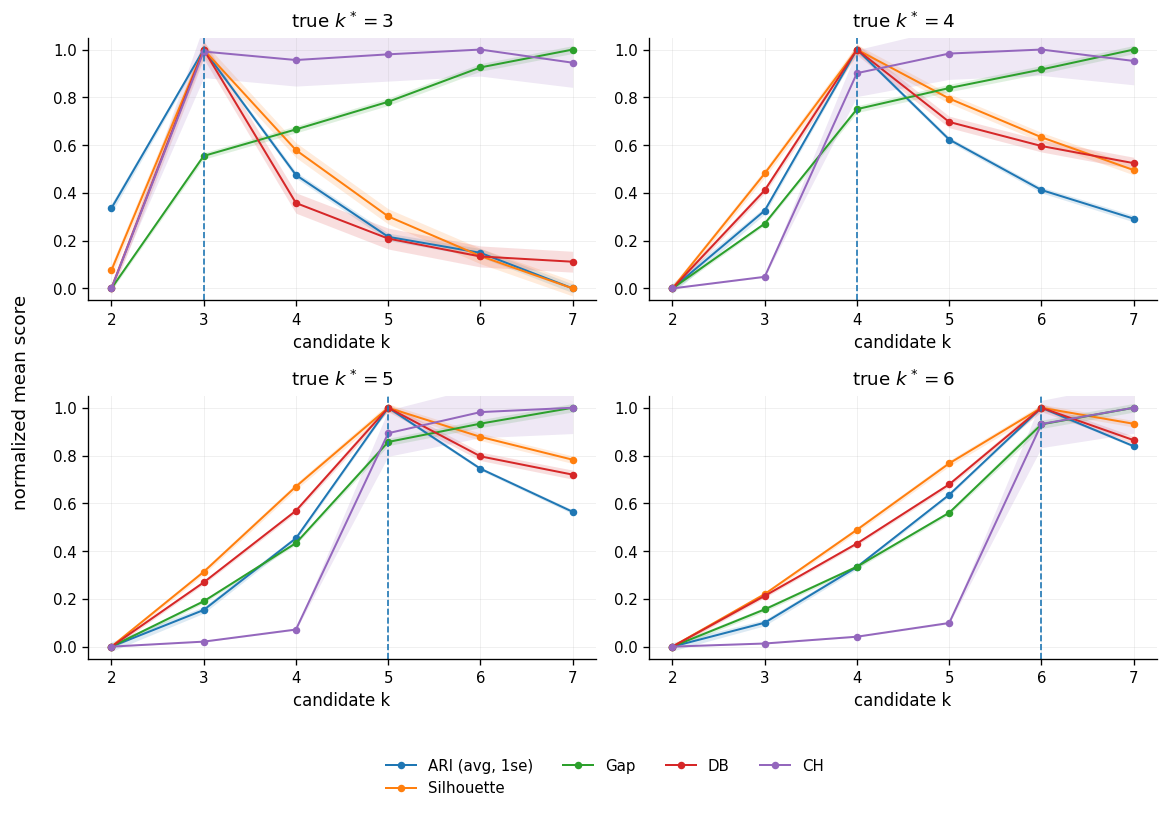

In [66]:
def plot_metric_profiles_by_true_k(
    results: pd.DataFrame,
    true_ks=(3, 4, 5, 6),
    PLOT_METRICS=PLOT_METRICS,
    show_se_band: bool = True,
    outpath: str | None = None,
):
    set_paper_style()
    df = filter_plot_metrics(results)

    agg = (
        df.groupby(["true_k", "metric_name", "k"], as_index=False)
          .agg(
              mean=("metric_value", "mean"),
              std=("metric_value", "std"),
              n=("metric_value", "size"),
          )
    )
    agg["se"] = agg["std"] / np.sqrt(agg["n"].clip(lower=1))

    # candidate ks
    ks = np.sort(df["k"].unique())

    fig, axes = plt.subplots(2, 2, figsize=(9.5, 6.8), constrained_layout=True)
    axes = axes.ravel()

    for ax, k_star in zip(axes, true_ks):
        sub = agg.loc[agg["true_k"] == k_star].copy()

        # one curve per metric
        for m in PLOT_METRICS:
            s = sub.loc[sub["metric_name"] == m].set_index("k").reindex(ks)

            y = s["mean"].to_numpy(dtype=float)
            se = s["se"].to_numpy(dtype=float)

            lo, hi = np.nanmin(y), np.nanmax(y)
            rng = hi - lo
            if not np.isfinite(rng) or rng == 0:
                y_norm = np.full_like(y, 0.5)
                se_norm = np.zeros_like(se)
            else:
                y_norm = (y - lo) / rng
                se_norm = se / rng
            y_plot, se_plot = y_norm, se_norm
            ax.set_ylim(-0.05, 1.05)

            line, = ax.plot(ks, y_plot, marker="o", linewidth=1.2, label=METRIC_LABEL[m])
            if show_se_band:
                ax.fill_between(
                    ks,
                    y_plot - se_plot,
                    y_plot + se_plot,
                    alpha=0.15,
                    linewidth=0,
                    color=line.get_color(),
                )

        ax.axvline(k_star, linestyle="--", linewidth=1.0)
        ax.set_title(r"true $k^* = %d$" % k_star)
        ax.set_xlabel("candidate k")
        ax.set_xticks(ks)

    # global legend 
    handles, labels = axes[0].get_legend_handles_labels()

    fig.text(-0.02, 0.5, "normalized mean score", va="center", rotation="vertical", fontsize=11)
    
    fig.legend(
        handles, labels,
        loc="lower center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 0),
    )
    
    fig.tight_layout(rect=(0, 0.10, 1, 1))

    if outpath is not None:
        fig.savefig(outpath, bbox_inches="tight")
    return fig


fig = plot_metric_profiles_by_true_k(results, PLOT_METRICS=PLOT_METRICS_EXT, outpath="fig_profiles_by_true_k.pdf")


/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_12723/983924354.py:77: UserWarning:

The figure layout has changed to tight



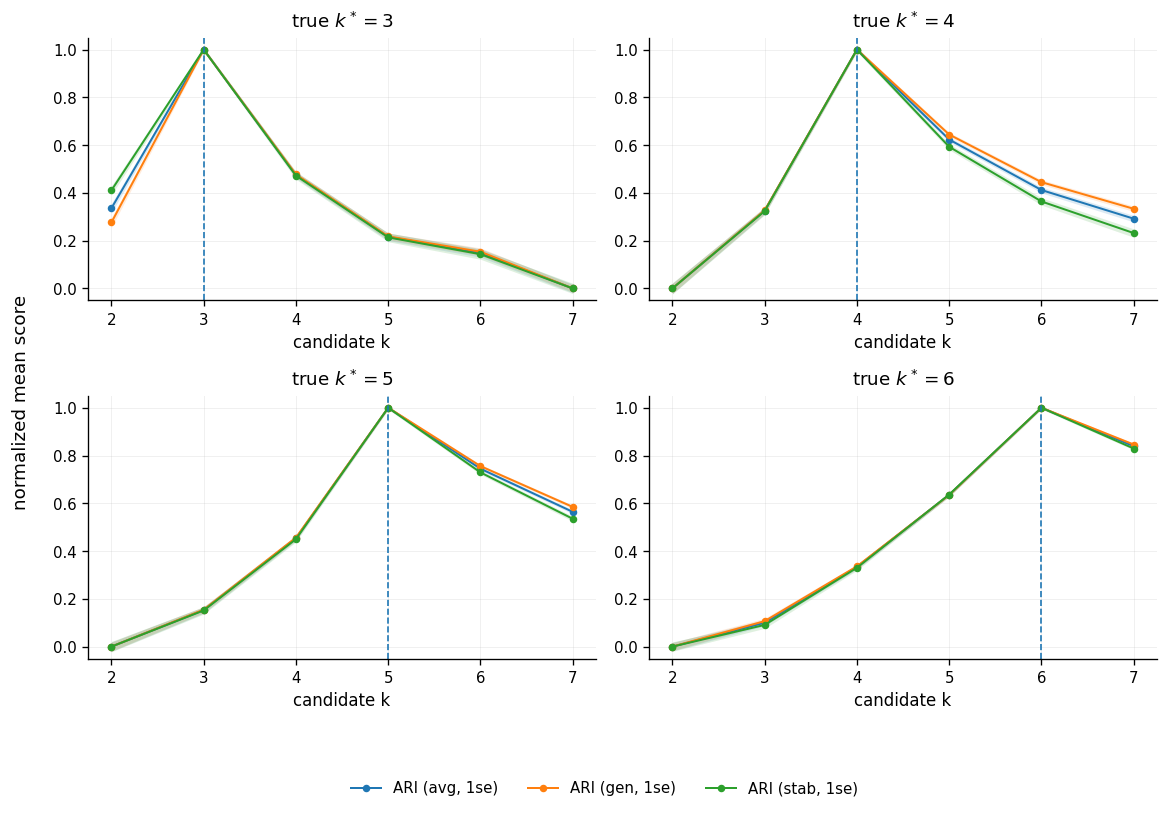

In [67]:

fig = plot_metric_profiles_by_true_k(results, PLOT_METRICS=PLOT_METRICS_CARVE, outpath="fig_profiles_by_true_k.pdf")

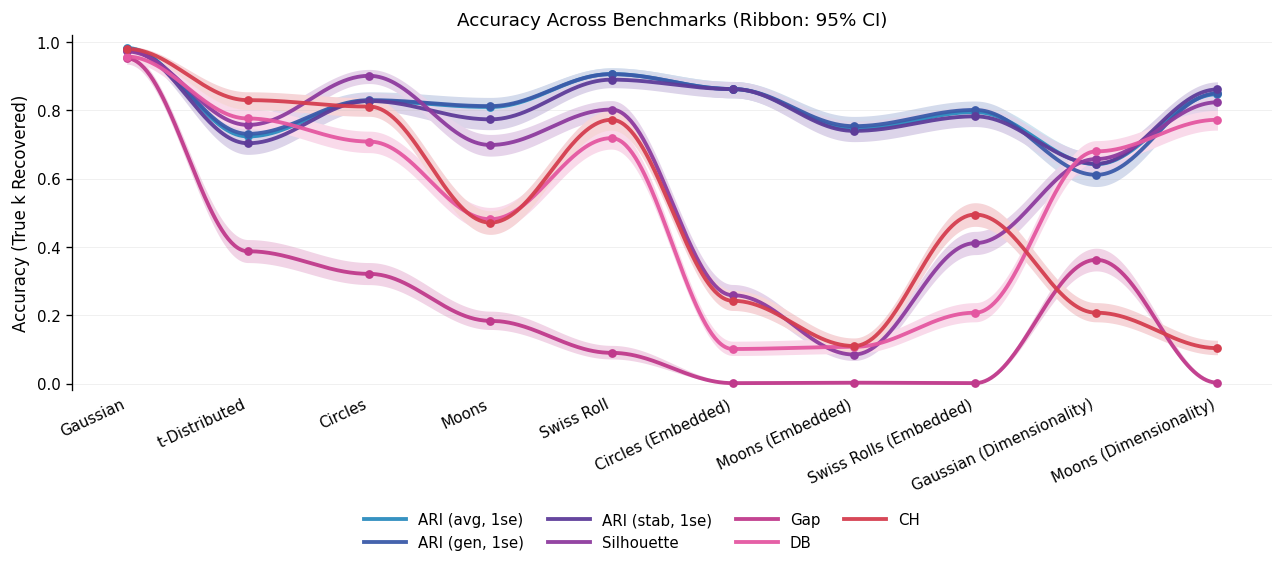

In [69]:
def instance_key_cols(df: pd.DataFrame) -> list[str]:
    base = ["benchmark", "metric_name", "dataset_id", "true_k"]
    cond = []
    for c in ["difficulty", "p"]:
        if c in df.columns and df[c].notna().any():
            cond.append(c)
    return base + cond

def accuracy_by_benchmark_with_ci(results: pd.DataFrame) -> pd.DataFrame:
    df = filter_plot_metrics(results)
    sel = df.loc[df["is_optimal"]].copy()

    key_cols = instance_key_cols(sel)
    if sel.duplicated(key_cols).any():
        sel = sel.sort_values(key_cols + ["k"]).drop_duplicates(key_cols, keep="first")

    out = (
        sel.groupby(["benchmark", "metric_name"], as_index=False)
           .agg(n=("is_correct", "size"), correct=("is_correct", "sum"))
    )
    out["accuracy"] = out["correct"] / out["n"].clip(lower=1)

    ci = [wilson_ci(int(r.correct), int(r.n)) for r in out.itertuples(index=False)]
    out["ci_low"] = [c[0] for c in ci]
    out["ci_high"] = [c[1] for c in ci]
    return out

def pastel_of(color, mix=0.72):
    r, g, b = to_rgb(color)
    return (r + (1 - r) * mix, g + (1 - g) * mix, b + (1 - b) * mix)

def _ease_interp(xi, yi, xfine):
    yfine = np.empty_like(xfine, dtype=float)
    for i in range(len(xi) - 1):
        m = (xfine >= xi[i]) & (xfine <= xi[i+1])
        t = (xfine[m] - xi[i]) / (xi[i+1] - xi[i])
        w = 0.5 - 0.5 * np.cos(np.pi * t)  # ease-in-out
        yfine[m] = (1 - w) * yi[i] + w * yi[i+1]
    yfine[xfine < xi[0]] = yi[0]
    yfine[xfine > xi[-1]] = yi[-1]
    return yfine

def prettify_benchmark_name(b: str) -> str:
    b = b.strip().lower().replace("-", "_")

    tags = []

    # tags / suffixes you use in filenames
    if "dimensionality" in b:
        tags.append("Dimensionality")
        b = b.replace("dimensionality_", "").replace("_dimensionality", "")

    embedded = False
    if "non_lin" in b or "nonlinear" in b or "embedded" in b:
        embedded = True
        b = b.replace("_non_lin", "").replace("_nonlinear", "").replace("_embedded", "")
    if embedded:
        tags.append("Embedded")

    # nice base names (fallback to title-case)
    base_map = {
        "swiss_rolls": "Swiss Rolls",
        "swiss_roll": "Swiss Roll",
        "gaussian": "Gaussian",
        "circles": "Circles",
        "moons": "Moons",
        "t": "t-Distributed",
        "t_dist": "t-Distributed",
        "t_distributed": "t-Distributed",
    }
    base = base_map.get(b, " ".join(w.capitalize() for w in b.split("_") if w))

    return f"{base} ({', '.join(tags)})" if tags else base

def plot_accuracy_ribbons(results, PLOT_METRICS=PLOT_METRICS, benchmark_order=None, outpath=None):
    set_paper_style()
    acc = accuracy_by_benchmark_with_ci(results)

    benchmarks = sorted(acc["benchmark"].unique()) if benchmark_order is None else benchmark_order
    x = np.arange(len(benchmarks), dtype=float)
    xfine = np.linspace(x.min(), x.max(), 700)

    fig, ax = plt.subplots(figsize=(10.8, 4.8), constrained_layout=False)

    handles = []
    labels = []

    for m in PLOT_METRICS:
        sub = acc.loc[acc["metric_name"] == m].set_index("benchmark").reindex(benchmarks)

        y  = sub["accuracy"].to_numpy(dtype=float)
        lo = sub["ci_low"].to_numpy(dtype=float)
        hi = sub["ci_high"].to_numpy(dtype=float)

        y_f  = _ease_interp(x, y,  xfine)
        lo_f = _ease_interp(x, lo, xfine)
        hi_f = _ease_interp(x, hi, xfine)

        base = METRIC_COLOR.get(m, "#4C78A8")
        band = pastel_of(base, mix=0.78)

        # ribbon
        ax.fill_between(xfine, lo_f, hi_f, color=band, alpha=1.0, linewidth=0, zorder=1)

        # centerline (this is what we put in legend)
        h, = ax.plot(xfine, y_f, color=base, linewidth=2.3, alpha=0.95, zorder=3)
        ax.scatter(x, y, color=base, s=18, zorder=4)

        handles.append(h)
        labels.append(METRIC_LABEL[m])

    pretty = [prettify_benchmark_name(b) for b in benchmarks]

    ax.set_xticks(x)
    ax.set_xticklabels(pretty, rotation=25, ha="right")
    ax.spines["bottom"].set_visible(False)
    ax.tick_params(axis="x", which="both", bottom=False, top=False, length=0, labelbottom=True)

    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel("Accuracy (True k Recovered)")
    ax.set_title("Accuracy Across Benchmarks (Ribbon: 95% CI)")

    ax.grid(axis="y", alpha=0.18)
    ax.grid(axis="x", visible=False)

    # legend below, "as usual"
    fig.legend(
        handles, labels,
        loc="lower center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 0.01),
        handlelength=2.8,
        columnspacing=1.6,
    )

    # reserve bottom margin for legend so it doesn't overlap ticks
    fig.tight_layout(rect=(0, 0.10, 1, 1))

    if outpath:
        fig.savefig(outpath, bbox_inches="tight")
    return fig


benchmark_order = [
    "gaussian",
    "t_dist",
    "circles",
    "moons",
    "swiss_roll",
    "circles_non_lin",
    "moons_non_lin",
    "swiss_rolls_non_lin",
    "dimensionality_gaussian",
    "dimensionality_moons",
]

fig = plot_accuracy_ribbons(results, outpath="fig_parallel_accuracy.pdf", benchmark_order=benchmark_order)

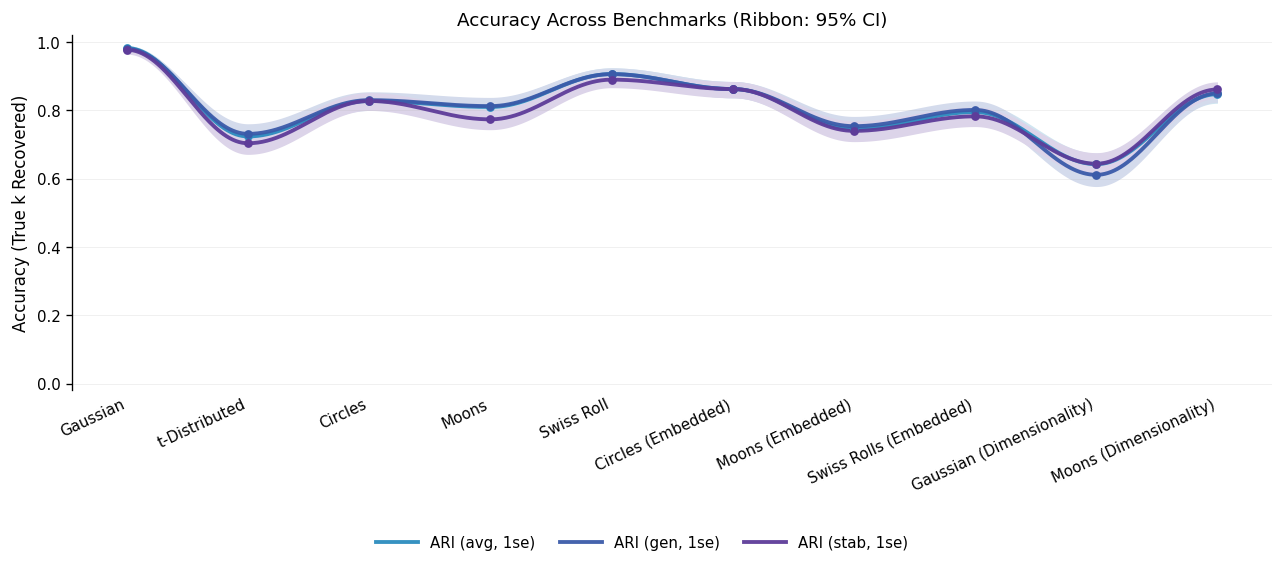

In [70]:

fig = plot_accuracy_ribbons(results, PLOT_METRICS=PLOT_METRICS_CARVE, outpath="fig_parallel_accuracy.pdf", benchmark_order=benchmark_order)

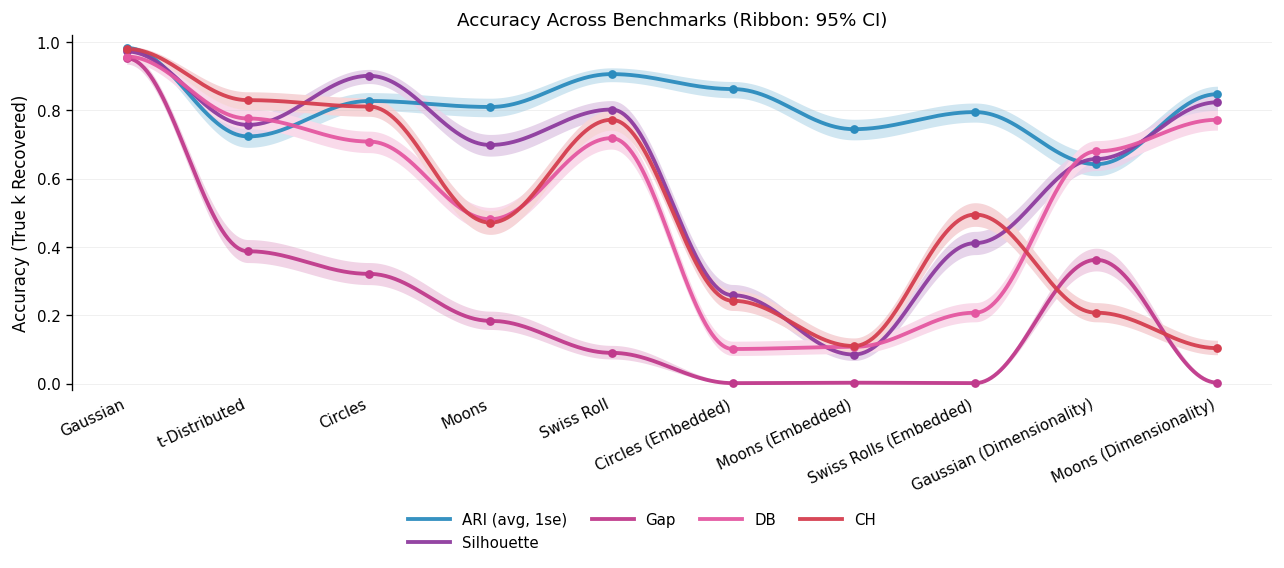

In [ ]:
fig = plot_accuracy_ribbons(results, PLOT_METRICS=PLOT_METRICS_EXT, outpath="fig_parallel_accuracy.pdf", benchmark_order=benchmark_order)

---